In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('/content/car_dataset.csv', header=None, na_values='?')

print("First 5 rows:\n")
print(data.head())



First 5 rows:

   0      1            2    3    4     5            6    7      8     9   ...  \
0   3    NaN  alfa-romero  gas  std   two  convertible  rwd  front  88.6  ...   
1   3    NaN  alfa-romero  gas  std   two  convertible  rwd  front  88.6  ...   
2   1    NaN  alfa-romero  gas  std   two    hatchback  rwd  front  94.5  ...   
3   2  164.0         audi  gas  std  four        sedan  fwd  front  99.8  ...   
4   2  164.0         audi  gas  std  four        sedan  4wd  front  99.4  ...   

    16    17    18    19    20     21      22  23  24       25  
0  130  mpfi  3.47  2.68   9.0  111.0  5000.0  21  27  13495.0  
1  130  mpfi  3.47  2.68   9.0  111.0  5000.0  21  27  16500.0  
2  152  mpfi  2.68  3.47   9.0  154.0  5000.0  19  26  16500.0  
3  109  mpfi  3.19  3.40  10.0  102.0  5500.0  24  30  13950.0  
4  136  mpfi  3.19  3.40   8.0  115.0  5500.0  18  22  17450.0  

[5 rows x 26 columns]


In [ ]:
data.columns = ["symboling","normalized_losses","make","fuel_type","aspiration",
                "num_doors","body_style","drive_wheels","engine_location",
                "wheel_base","length","width","height","curb_weight",
                "engine_type","num_cylinders","engine_size","fuel_system",
                "bore","stroke","compression_ratio","horsepower","peak_rpm",
                "city_mpg","highway_mpg","price"]

print("After assigning column names:\n")
print(data.head())

After assigning column names:

   symboling  normalized_losses         make fuel_type aspiration num_doors  \
0          3                NaN  alfa-romero       gas        std       two   
1          3                NaN  alfa-romero       gas        std       two   
2          1                NaN  alfa-romero       gas        std       two   
3          2              164.0         audi       gas        std      four   
4          2              164.0         audi       gas        std      four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel_system  bore  stroke co

In [ ]:
print("Missing Values:\n")
print(data.isnull().sum())

Missing Values:

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


In [ ]:
#handling missing values numeric to mean
num_cols = data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

print("After filling numeric missing values:\n")
print(data[num_cols].head())

After filling numeric missing values:

   symboling  normalized_losses  wheel_base  length  width  height  \
0          3              122.0        88.6   168.8   64.1    48.8   
1          3              122.0        88.6   168.8   64.1    48.8   
2          1              122.0        94.5   171.2   65.5    52.4   
3          2              164.0        99.8   176.6   66.2    54.3   
4          2              164.0        99.4   176.6   66.4    54.3   

   curb_weight  engine_size  bore  stroke  compression_ratio  horsepower  \
0         2548          130  3.47    2.68                9.0       111.0   
1         2548          130  3.47    2.68                9.0       111.0   
2         2823          152  2.68    3.47                9.0       154.0   
3         2337          109  3.19    3.40               10.0       102.0   
4         2824          136  3.19    3.40                8.0       115.0   

   peak_rpm  city_mpg  highway_mpg    price  
0    5000.0        21           27  1

In [ ]:
#categorical to mode
cat_cols = data.select_dtypes(include=['object']).columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print("After filling categorical missing values:\n")
print(data[cat_cols].head())

After filling categorical missing values:

          make fuel_type aspiration num_doors   body_style drive_wheels  \
0  alfa-romero       gas        std       two  convertible          rwd   
1  alfa-romero       gas        std       two  convertible          rwd   
2  alfa-romero       gas        std       two    hatchback          rwd   
3         audi       gas        std      four        sedan          fwd   
4         audi       gas        std      four        sedan          4wd   

  engine_location engine_type num_cylinders fuel_system  
0           front        dohc          four        mpfi  
1           front        dohc          four        mpfi  
2           front        ohcv           six        mpfi  
3           front         ohc          four        mpfi  
4           front         ohc          five        mpfi  


In [ ]:
#coverting data types
cols_to_convert = ["normalized_losses","bore","stroke","horsepower","peak_rpm","price"]

for col in cols_to_convert:
    data[col] = pd.to_numeric(data[col])

print("After type conversion:\n")
print(data[cols_to_convert].dtypes)

After type conversion:

normalized_losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak_rpm             float64
price                float64
dtype: object


In [ ]:
#encoding categorical data
data = pd.get_dummies(data, drop_first=True)

print("After encoding:\n")
print(data.head())

After encoding:

   symboling  normalized_losses  wheel_base  length  width  height  \
0          3              122.0        88.6   168.8   64.1    48.8   
1          3              122.0        88.6   168.8   64.1    48.8   
2          1              122.0        94.5   171.2   65.5    52.4   
3          2              164.0        99.8   176.6   66.2    54.3   
4          2              164.0        99.4   176.6   66.4    54.3   

   curb_weight  engine_size  bore  stroke  ...  num_cylinders_three  \
0         2548          130  3.47    2.68  ...                False   
1         2548          130  3.47    2.68  ...                False   
2         2823          152  2.68    3.47  ...                False   
3         2337          109  3.19    3.40  ...                False   
4         2824          136  3.19    3.40  ...                False   

   num_cylinders_twelve  num_cylinders_two  fuel_system_2bbl  \
0                 False              False             False   
1      

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("After scaling (first 5 rows):\n")
print(scaled_data[:5])

After scaling (first 5 rows):

[[ 1.74347043  0.         -1.6907718  -0.42652147 -0.84478235 -2.0204173
  -0.01456628  0.07444893  0.51908935 -1.83940375 -0.28834891  0.17106493
  -0.263484   -0.64655303 -0.54605874  0.03667351 -0.18802536 -0.20151709
  -0.12186667 -0.21428571 -0.26020825 -0.14106912 -0.12186667 -0.30070838
  -0.20151709 -0.070014   -0.26020825 -0.31025261 -0.23811978 -0.18802536
  -0.15811388 -0.09925833 -0.17363972 -0.24935149 -0.43008266 -0.24935149
  -0.23811978  0.32879797 -0.46929532  1.14165266 -0.20151709 -0.7200823
  -0.93847426 -0.372678   -1.18817705  1.30283093 -0.12186667 -0.070014
  -0.24935149 -1.61136316 -0.28097574 -0.26020825 -0.14106912 -0.23811978
   0.53787375 -0.36413828 -0.070014   -0.070014   -0.14106912 -0.68907194
  -0.12186667 -0.32879797 -0.070014    1.08666971 -0.21428571 -0.070014  ]
 [ 1.74347043  0.         -1.6907718  -0.42652147 -0.84478235 -2.0204173
  -0.01456628  0.07444893  0.51908935 -1.83940375 -0.28834891  0.17106493
  -0.263484

In [ ]:
print("Final Shape of Data:", scaled_data.shape)

Final Shape of Data: (205, 66)


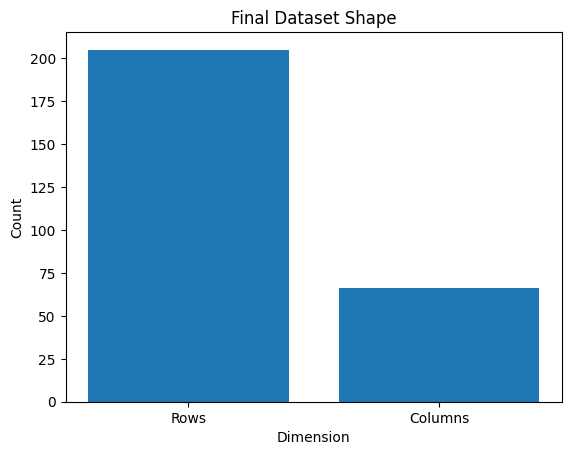

In [ ]:
#visualize final shape
import matplotlib.pyplot as plt

# Data for graph
labels = ['Rows', 'Columns']
values = [scaled_data.shape[0], scaled_data.shape[1]]

# Plot graph
plt.figure()
plt.bar(labels, values)

plt.title("Final Dataset Shape")
plt.xlabel("Dimension")
plt.ylabel("Count")

plt.show()